# 01 - Construcción y caracterización de la cohorte.

En este notebook se construye la cohorte analítica a partir de la base original del proyecto FONIS y
se caracteriza: curación y tipado según el catálogo, definición del desenlace, cribado de predictores,
sesgo de selección, análisis bivariado y heterogeneidad entre centros.

**Entrada:**
1. Base de datos FONIS (RedCAP)
2. Catálogo metadatos

**Salida:**
1. Parquet de la cohorte analítica y de la subcohorte espinal
2. Tablas del manuscrito de la cohorte y sus anexos
3. Figuras de flujo, frecuencia del desenlace y heterogeneidad

Este notebook no ajusta modelos. Su función es dejar una cohorte única y documentada, de modo que el
análisis de asociaciones y el predictivo partan de la misma definición. El cribado rige la selección
de predictores de esos modelos, no la caracterización descriptiva, que se hace sobre la cohorte
completa.

In [1]:

%load_ext autoreload
%autoreload 2

import sys, warnings
from pathlib import Path

import pandas as pd

sys.path.insert(0, str(Path.cwd()))
from utils import config, daten, statistik, vista, rendern, tabula

%matplotlib inline
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)

pd.set_option("display.max_rows", 250)

catalogo = daten.cargar_catalogo()
catalogo.shape

✔ contrato válido: 144 variables · 24 columnas blindadas


(144, 27)

## 1. Ingesta y curación

Los datos provienen del proyecto FONIS SA21I0036, registrados en REDCap y exportados a un único
archivo. La curación renombra cada variable según el catálogo, la tipifica según su naturaleza como
binaria, nominal, ordinal o numérica, y fija el orden clínico de las ordinales, que un orden
alfabético alteraría. El diccionario de las variables originales se reproduce como anexo.

In [2]:
crudo = daten.cargar_raw()
cohorte_cruda = daten.curar(crudo, catalogo)

print(f"registros: {len(cohorte_cruda)} · variables: {cohorte_cruda.shape[1]}")
print(f"tipado: {cohorte_cruda.dtypes.astype(str).value_counts().to_dict()}")

pd.DataFrame([{"variable": v,
               "niveles en orden clínico": " · ".join(cohorte_cruda[v].cat.categories)}
              for v in ("asa", "duracion_cesarea", "morf_it")])

registros: 770 · variables: 130
tipado: {'boolean': 63, 'category': 53, 'Int64': 10, 'datetime64[ns]': 2, 'float64': 2}


,variable,niveles en orden clínico
0,asa,II · III
1,duracion_cesarea,< 30 min · 31-60 min · > 60 min
2,morf_it,No · 50 mcg · 80 mcg · 100 mcg · > 100 mcg


In [3]:
# Anexo - diccionario de las variables originales del proyecto FONIS.

variables_fonis = pd.read_excel(config.VARIABLES_FONIS, header=0)
variables_fonis.columns = ["Variable", "Descripción"]
variables_fonis["Bloque"] = (variables_fonis["Variable"]
                             .where(variables_fonis["Descripción"].isna()).ffill())
variables_fonis = variables_fonis[variables_fonis["Descripción"].notna()].reset_index(drop=True)

assert variables_fonis["Bloque"].notna().all(), "hay filas antes de la primera sección"
print(f"{len(variables_fonis)} variables · "
      + " · ".join(f"{b} {n}" for b, n in variables_fonis["Bloque"].value_counts()
                   .reindex(variables_fonis["Bloque"].unique()).items()))

anexo_variables_fonis = variables_fonis[["Bloque", "Variable", "Descripción"]]
tabula.construir_docx(
    anexo_variables_fonis,
    tabula.Spec(config.TABLAS_MANUSCRITO["AN_variables_fonis"],
                "Anexo. Variables recolectadas por el proyecto FONIS y su descripción",
                nota="Variables originales del proyecto FONIS SA21I0036 tal como fueron "
                     "recolectadas, agrupadas según su relación temporal con la cesárea. No "
                     "incluye los campos administrativos del formulario -identificador, "
                     "consentimiento, marcas de completitud y registro del cuentapasos- ni las "
                     "variables derivadas para el análisis, que se describen en "
                     "\\cref{sec:variables-preparacion-datos}.",
                grupo="Bloque"))

anexo_variables_fonis

119 variables · Preoperatorias 37 · Intraoperatorias 30 · Postoperatorias 52
✔ tabla_AN_variables_fonis.docx  (119 filas)
✔ tabla_AN_variables_fonis.tex  (119 filas)


,Bloque,Variable,Descripción
0,Preoperatorias,Hospital,Centro donde fue atendida la paciente. Registr...
1,Preoperatorias,Fecha de nacimiento,Fecha de nacimiento materna. Registrado por el...
2,Preoperatorias,Fecha de la cesárea,Fecha de realización de la cesárea. Registrado...
3,Preoperatorias,Edad,Edad materna en años cumplidos al momento de l...
4,Preoperatorias,Peso (kg),Peso materno en kilogramos al momento de la ev...
5,Preoperatorias,Altura (cm),"Talla en centímetros, medida en evaluación pre..."
6,Preoperatorias,IMC,"IMC calculado como peso (kg) / talla (m²), a p..."
7,Preoperatorias,Edad gestacional (semanas),"Edad gestacional al momento de la cesárea, en ..."
8,Preoperatorias,Gestaciones,Número total de embarazos previos y actual. Re...
9,Preoperatorias,Partos,Número de partos previos. Registrado desde fic...


## 2. Desenlace y cohorte analítica

El desenlace principal es una variable binaria compuesta, definida como una intensidad de 4 o más en
la escala numérica del dolor en al menos una de las tres mediciones de la primera semana, a las 24
horas, 48 horas y séptimo día.

Sobre las pacientes reclutadas se aplican los criterios de elegibilidad del protocolo verificables en
el registro y, a continuación, el criterio propio de esta tesis, que exige seguimiento completo del
desenlace. La subcohorte espinal se deriva aquí y sostiene los análisis de sensibilidad del segundo
cuaderno.

In [4]:
con_desenlace = daten.construir_desenlace(cohorte_cruda)
clasificada = daten.clasificar_elegibilidad(con_desenlace)
cohorte, flujo = daten.construir_cohorte(con_desenlace)

flujo

,criterio,estrato,n_excluidas,n_restante
0,Edad < 18 años,protocolo,3,767
1,Edad gestacional < 28 semanas,protocolo,0,767
2,Sin consentimiento informado,protocolo,19,748
3,Anestesia general,protocolo,5,743
4,Seguimiento incompleto,seguimiento,29,714
5,Cohorte analítica,NaN,<NA>,714


In [5]:
espinal = cohorte[cohorte["tec_anest"].astype(str).str.lower().eq("espinal")].copy()

print(f"cohorte analítica: {len(cohorte)} · subcohorte espinal: {len(espinal)}")
print(f"eventos: {int(cohorte['dmg_1s_bin'].sum())} "
      f"({100 * cohorte['dmg_1s_bin'].mean():.1f} %)")

cohorte analítica: 714 · subcohorte espinal: 690
eventos: 423 (59.2 %)


✔ fig_flujo_participantes.png · fig_flujo_participantes.svg


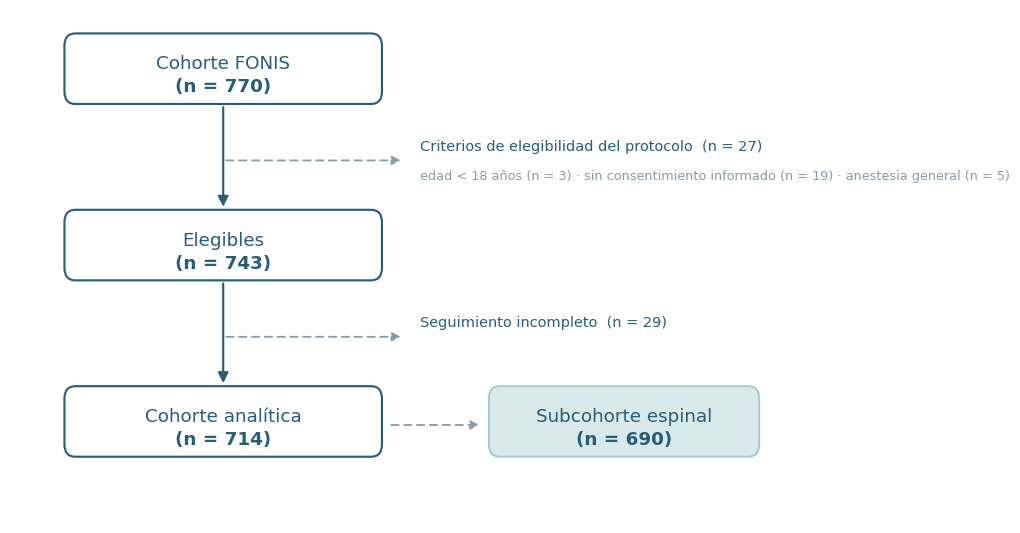

In [6]:
etapas = vista.flujo_participantes(flujo)
fig = rendern.flujo_participantes(etapas, n_inicial=len(con_desenlace), n_espinal=len(espinal))
rendern.guardar(fig, "fig_flujo_participantes")

fig

## 3. Cribado de predictores

El cribado decide qué variables pueden entrar a los modelos. Retira primero las no utilizables como
predictores, esto es, las mediciones de dolor de las que deriva el desenlace, las registradas con
posterioridad a la primera medición y las administrativas o de identificación. Aplica después los
criterios cuantitativos de datos faltantes y de variabilidad.

Su alcance se limita a la selección de predictores. La caracterización descriptiva de la cohorte se
realiza sobre el conjunto completo de variables evaluables, con independencia de este cribado.

In [7]:
cribado = daten.cribar(cohorte, catalogo)

evaluables = cribado[cribado["evaluable"]]
print(f"evaluables: {len(evaluables)} · candidatos automáticos: {int(evaluables['candidato'].sum())}")
evaluables["motivo"].value_counts(dropna=False)

evaluables: 84 · candidatos automáticos: 45


motivo
None                               49
categoria_dominante_extrema        19
NaN                                 6
ordinal_concentrada_en_un_nivel     4
un_solo_nivel_observado             3
muy_pocos_datos_observados          3
Name: count, dtype: int64

In [8]:
# Causa de exclusión de cada variable (insumo del anexo)
excluidas = daten.causas_exclusion(catalogo, cribado)

print(f"variables excluidas: {len(excluidas)}")
excluidas["exclusion_causa"].value_counts()

variables excluidas: 91


exclusion_causa
Posterior a primera medición      36
Baja variabilidad                 23
Pérdida de datos > 5%              9
Administrativa                     9
Exclusión manual                   6
Identificador                      3
Desenlace o medición del dolor     3
Texto libre                        2
Name: count, dtype: int64

In [9]:
anexo_excluidas = tabula.tabla_excluidas(excluidas, None)
tabula.construir_docx(
    anexo_excluidas,
    tabula.Spec(config.TABLAS_MANUSCRITO["variables_excluidas"],
                "Anexo. Variables excluidas del análisis y su causa",
                nota="De las variables del catálogo, las incluidas conforman los predictores del "
                     "análisis; las restantes se excluyeron por la causa indicada.",
                grupo="Bloque", cols=["Variable", "Causa"]))

anexo_excluidas

✔ tabla_variables_excluidas.docx  (91 filas)
✔ tabla_variables_excluidas.tex  (91 filas)


,Bloque,Variable,Causa
0,Preoperatorio,Identificación,Identificador
1,Preoperatorio,Fecha de Nacimiento,Identificador
2,Preoperatorio,Fecha de la Cesárea,Identificador
3,Preoperatorio,Peso (kg),Se mantiene IMC
4,Preoperatorio,Altura (cm),Se mantiene IMC
5,Preoperatorio,Gestaciones,"Pérdida 9,2%"
6,Preoperatorio,Partos,Pérdida 31%
7,Preoperatorio,Abortos,"Pérdida 76,3%"
8,Preoperatorio,Parto prematuro,Categoría dominante ≥ 95% o categoría rara < 5...
9,Preoperatorio,Cirugía no obstétrica durante el embarazo,Categoría dominante ≥ 95% o categoría rara < 5...


## 4. Sesgo de selección

Para valorar un posible sesgo de selección se comparan las características basales preoperatorias de
las pacientes incluidas y las excluidas, distinguiendo las dos vías de exclusión, criterios del
protocolo y seguimiento incompleto. El balance se mide mediante la diferencia de medias
estandarizada (SMD), considerándose relevante una magnitud igual o superior al umbral declarado.

Los faltantes quedan fuera del contraste y no se tratan como una categoría adicional, de modo que la
prueba mida la variable y no su completitud.

In [10]:
sesgo = daten.comparar_incluidas_excluidas(clasificada, catalogo)

for estrato, g in sesgo.groupby("estrato"):
    sig = g[g["p"] < 0.05]
    print(f"{estrato:12s} · {len(g)} variables · significativas: {len(sig)} "
          f"· |SMD| ≥ {config.SMD_UMBRAL}: {int((g['smd'].abs() >= config.SMD_UMBRAL).sum())}")

sesgo[sesgo["p"] < 0.05].round(3)

protocolo    · 35 variables · significativas: 2 · |SMD| ≥ 0.2: 15
seguimiento  · 35 variables · significativas: 1 · |SMD| ≥ 0.2: 10


,estrato,var_rename,n_incluidas,n_excluidas,smd,prueba,p
11,protocolo,ne,702,26,0.489,χ²,0.041
26,protocolo,dc,707,27,-0.348,Fisher,0.041
35,seguimiento,hosp,714,29,0.551,χ²,0.003


In [11]:
anexo_sesgo = tabula.tabla_sesgo_seleccion(vista.tabla_sesgo_seleccion(clasificada, sesgo, catalogo))
tabula.construir_docx(
    anexo_sesgo,
    tabula.Spec(config.TABLAS_MANUSCRITO["sesgo_seleccion"],
                "Anexo. Comparación de características basales preoperatorias entre las pacientes "
                "incluidas y las excluidas",
                nota="Continuas: mediana [RIC]. Categóricas: n/N (%) sobre casos observados. SMD: "
                     "diferencia de medias estandarizada, en valor absoluto. Frágil señala binarias "
                     "con menos de cinco eventos entre las excluidas, donde la estimación de la SMD "
                     "es inestable. Prueba: χ² o exacta de Fisher en categóricas, Mann-Whitney en "
                     "ordinales y numéricas. En negrita, p < 0,05.",
                grupo="Grupo",
                cols=["Variable", "Incluidas (n=714)", "Excluidas",
                      "SMD", "Prueba", "p"],
                apaisada=True))

anexo_sesgo

✔ tabla_SS_sesgo_seleccion.docx  (70 filas)
✔ tabla_SS_sesgo_seleccion.tex  (70 filas)  → requiere apaisada en el anexo


,Grupo,Variable,Incluidas (n=714),Excluidas,SMD,Prueba,p
0,Excluidas por criterios del protocolo (n=27),Nivel educacional,Superior (50%),Secundario (69%),"0,489",χ²,"0,041"
1,Excluidas por criterios del protocolo (n=27),Clasificación ASA,II (93%),II (100%),"0,385",Fisher,"0,407"
2,Excluidas por criterios del protocolo (n=27),Antecedente de dolor crónico,"49/707 (6,9%)","5/27 (18,5%)","0,348",Fisher,"0,041"
3,Excluidas por criterios del protocolo (n=27),Tabaquismo previo al embarazo,"194/708 (27,4%)","4/27 (14,8%)","0,308",χ²,"0,220"
4,Excluidas por criterios del protocolo (n=27),Edad gestacional (semanas),38.0 [37.0–39.0],38.0 [37.0–38.0],"0,306",Mann-Whitney,"0,055"
5,Excluidas por criterios del protocolo (n=27),Parto prematuro,"31/714 (4,3%)","0/27 (0,0%)","0,298",Fisher,"0,622"
6,Excluidas por criterios del protocolo (n=27),IMC,33.2 [29.8–37.4],32.0 [29.6–34.5],"0,290",Mann-Whitney,"0,168"
7,Excluidas por criterios del protocolo (n=27),Hospital,HCVB (28%),HCVB (41%),"0,274",χ²,"0,514"
8,Excluidas por criterios del protocolo (n=27),Cirugía pélvica previa,"76/714 (10,6%)","1/27 (3,7%)","0,269",Fisher,"0,347"
9,Excluidas por criterios del protocolo (n=27),Incompetencia cervical,"1/714 (0,1%)","1/27 (3,7%)","0,260",Fisher,"0,072"


## 5. Características de la cohorte y análisis bivariado

Se describen las variables evaluables y se estima la asociación cruda de cada una con el desenlace.
La medida de efecto depende del tipo de variable: odds ratio en las binarias, V de Cramér en las
nominales de más de dos niveles, y correlación rango-biserial o d de Cohen en las ordinales y
numéricas según la prueba empleada.

El análisis es exploratorio y sirve de apoyo a la selección de predictores. Se realiza sobre la
cohorte completa.

In [12]:
desenlace = cohorte[config.OUTCOME]
tipos = dict(zip(catalogo["var_rename"], catalogo["conceptual_type"]))

filas = []
for _, r in catalogo[catalogo["prelim_role"].isin(config.ROLES_EVAL)].iterrows():
    v = r["var_rename"]
    if v not in cohorte.columns or v == config.CENTER_VAR:
        continue
    filas.append({"variable": r["label"], "bloque": r["block"],
                  **statistik.resumen(cohorte[v], tipos[v]),
                  **statistik.bivariado(cohorte[v], desenlace, tipos[v])})

bivariado = pd.DataFrame(filas)
print(f"variables descritas: {len(bivariado)}")
bivariado[bivariado["p"] < 0.05][["variable", "bloque", "resumen", "efecto", "prueba", "p"]].round(4)

variables descritas: 78


,variable,bloque,resumen,efecto,prueba,p
5,Gestaciones,preop,2.0 [1.0–3.0],r = +0.14,M-W,0.0018
18,Infección obstétrica,preop,21/714 (2.9%),3.00 [1.00–9.02],χ²,0.0399
22,Cirugía pélvica previa,preop,76/714 (10.6%),1.67 [1.00–2.79],χ²,0.0489
24,Otras comorbilidades,preop,315/714 (44.1%),0.50 [0.37–0.67],χ²,0.0000
33,Ansiedad preoperatoria (HADS-A >=8),preop,192/709 (27.1%),1.78 [1.25–2.52],χ²,0.0012
34,Depresión preoperatoria (HADS-D >=8),preop,57/706 (8.1%),2.26 [1.21–4.21],χ²,0.0087
41,PNV - Dexametasona,intraop,4 mg: 498/713 (69.8%); 8 mg: 127/713 (17.8%); ...,r = -0.08,M-W,0.0184
44,Dipirona intraoperatoria,intraop,2 g: 436/713 (61.2%); No: 241/713 (33.8%); 1 g...,r = +0.18,M-W,0.0000
46,Ketorolaco intraoperatorio,intraop,No: 473/711 (66.5%); 60 mg: 161/711 (22.6%); 3...,r = -0.08,M-W,0.0208
47,Paracetamol intraoperatorio,intraop,274/712 (38.5%),0.42 [0.31–0.57],χ²,0.0000


In [13]:
descriptiva = vista.tabla_descriptiva(cohorte, catalogo)
anexo_descriptiva = tabula.tabla_descriptiva(descriptiva)
tabula.construir_docx(
    anexo_descriptiva,
    tabula.Spec(config.TABLAS_MANUSCRITO["DM_descriptiva_maestra"],
                "Características de la cohorte analítica y análisis bivariado con el desenlace",
                nota="Continuas: mediana [RIC]. Categóricas: n/N (%) sobre casos observados. Las "
                     "variables de más de dos niveles listan sus categorías debajo, precedidas de "
                     "un punto medio; la prueba y la medida cruda se estiman una vez por variable, "
                     "de modo que no se repiten en esas filas. Medida cruda según el tipo: odds "
                     "ratio con IC 95 % en tablas 2×2, V de Cramér en nominales de más de dos "
                     "niveles, correlación rango-biserial (r) en las contrastadas con "
                     "Mann-Whitney y d de Cohen en las contrastadas con t de Welch. Prueba: χ² o "
                     "exacta de Fisher en categóricas, Mann-Whitney o t de Welch en ordinales y "
                     "numéricas. Un guion indica que la variable no presentó variabilidad "
                     "suficiente para estimar el contraste. En negrita, las asociaciones con "
                     "p < 0,05.",
                grupo="Bloque", cols=["Variable", "Global", "Faltantes", "n análisis",
                                      "Prueba", "p (vs desenlace)", "Medida cruda"],
                pagina_completa=True))

anexo_descriptiva

✔ tabla_DM_descriptiva_maestra.docx  (179 filas)
✔ tabla_DM_descriptiva_maestra.tex  (179 filas)  → requiere apaisada en el anexo


,Bloque,Variable,Global,Faltantes,n análisis,Prueba,p (vs desenlace),Medida cruda,p
0,Preoperatorio,Abortos,"1,0 [1,0–2,0]","545 (76,3%)",169,M-W,"0,195","r = +0,09",1.950427e-01
1,Preoperatorio,Altura (cm),"159,0 [155,0–163,0]","4 (0,6%)",710,t-Welch,"0,990","d = -0,00",9.899436e-01
2,Preoperatorio,Ansiedad preoperatoria (HADS-A >=8),"192/709 (27,1%)","5 (0,7%)",709,χ²,"0,001","OR 1,78 [1,25–2,52]",1.235155e-03
3,Preoperatorio,Antecedente de dolor crónico,"49/707 (6,9%)","7 (1,0%)",707,χ²,"0,756","OR 1,10 [0,61–1,99]",7.564354e-01
4,Preoperatorio,Cesárea previa,"377/714 (52,8%)","0 (0,0%)",714,χ²,"0,243","OR 1,19 [0,89–1,61]",2.430941e-01
5,Preoperatorio,Cirugía no obstétrica durante el embarazo,"1/714 (0,1%)","0 (0,0%)",714,Fisher,"0,408","OR 0,23 [0,01–5,63]",4.075630e-01
6,Preoperatorio,Cirugía pélvica previa,"76/714 (10,6%)","0 (0,0%)",714,χ²,"0,049","OR 1,67 [1,00–2,79]",4.890779e-02
7,Preoperatorio,Clasificación ASA,II (93%),"13 (1,8%)",701,χ²,"0,692","OR 1,13 [0,62–2,04]",6.915200e-01
8,Preoperatorio,DC: AINES,"9/714 (1,3%)","0 (0,0%)",714,Fisher,"0,323","OR 2,43 [0,50–11,79]",3.228023e-01
9,Preoperatorio,DC: Anticonvulsivante,"3/714 (0,4%)","0 (0,0%)",714,Fisher,"0,570","OR 0,34 [0,03–3,79]",5.700684e-01


## 6. Frecuencia del desenlace

Se reporta la incidencia acumulada del desenlace durante la primera semana y su desagregación por
momento de medición y por centro, con intervalos de Wilson y un contraste global entre hospitales.

Se describe además la distribución de la severidad del dolor, que distingue ausente o leve, moderado
e intenso, y su evolución en los tres momentos de medición.

In [14]:
incidencia = statistik.frecuencia_por_centro(desenlace, cohorte[config.CENTER_VAR])
print(f"p global (χ²) = {incidencia.attrs['p_global']:.3g}")

incidencia.assign(**{"%": (100 * incidencia["incidencia"]).round(1)})

p global (χ²) = 3.67e-31


,centro,n,eventos,no_eventos,incidencia,ic_low,ic_high,%
0,HCUCH,180,125,55,0.694444,0.623670,0.757092,69.4
1,HCVB,198,174,24,0.878788,0.825980,0.917178,87.9
2,HLTB,185,66,119,0.356757,0.291285,0.428057,35.7
3,HSJD,151,58,93,0.384106,0.310318,0.463645,38.4
4,GLOBAL,714,423,291,0.592437,0.555993,0.627892,59.2


In [15]:
# Frecuencia por momento de medición
for v, etiqueta in [("dmg_24h", "24 horas"), ("dmg_48h", "48 horas"), ("dmg_7d", "7 días")]:
    s = cohorte[v].dropna()
    print(f"{etiqueta:>9s}: {100 * s.mean():.1f} % ({int(s.sum())}/{len(s)})")

 24 horas: 33.8 % (241/714)
 48 horas: 21.1 % (151/714)
   7 días: 38.4 % (274/714)


✔ fig_distribucion_desenlace.png · fig_distribucion_desenlace.svg


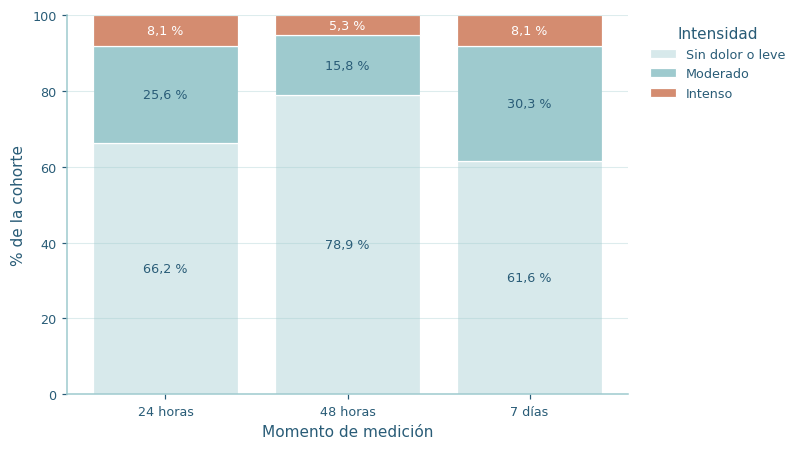

In [16]:
severidad = vista.distribucion_desenlace(cohorte)

fig = rendern.distribucion_desenlace(severidad)
rendern.guardar(fig, "fig_distribucion_desenlace")
fig

✔ fig_incidencia_por_centro.png · fig_incidencia_por_centro.svg


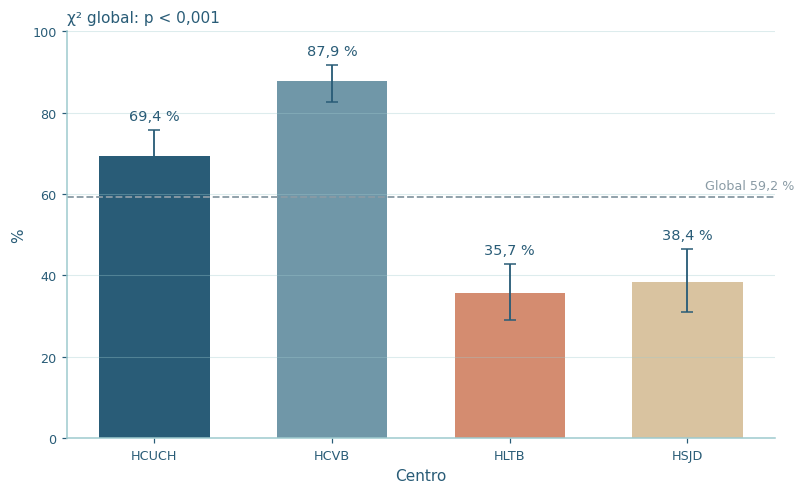

In [17]:
fig = rendern.incidencia_por_centro(incidencia)
rendern.guardar(fig, "fig_incidencia_por_centro")
fig

In [18]:
frecuencia_severidad = vista.frecuencia_severidad_tiempo(cohorte)
rendern.guardar(rendern.frecuencia_severidad_tiempo(frecuencia_severidad),
                "fig_frecuencia_severidad_tiempo")

frecuencia_centro = vista.frecuencia_por_centro_tiempo(cohorte)
rendern.guardar(rendern.frecuencia_por_centro_tiempo(frecuencia_centro),
                "fig_frecuencia_centro_tiempo")

✔ fig_frecuencia_severidad_tiempo.png · fig_frecuencia_severidad_tiempo.svg
✔ fig_frecuencia_centro_tiempo.png · fig_frecuencia_centro_tiempo.svg


In [19]:
tabula.construir_docx(
    tabula.tabla_frecuencia_severidad(frecuencia_severidad),
    tabula.Spec(config.TABLAS_MANUSCRITO["FS_frecuencia_severidad"],
                "Frecuencia de dolor por momento de medición y umbral clínico",
                nota="Con dolor: proporción con END > 0, no excluyente de las tres categorías "
                     "siguientes, que sí lo son entre sí. n/N (%) sobre casos observados en cada "
                     "momento.",
                cols=["Categoría", "24 horas", "48 horas", "7 días"]))

✔ tabla_FS_frecuencia_severidad.docx  (4 filas)
✔ tabla_FS_frecuencia_severidad.tex  (4 filas)


In [20]:
for momento, p in frecuencia_centro.attrs["p_global"].items():
    print(f"p global (χ²) a las {momento} = {p:.3g}")

tabula.construir_docx(
    tabula.tabla_frecuencia_centro_tiempo(frecuencia_centro),
    tabula.Spec(config.TABLAS_MANUSCRITO["FC_frecuencia_centro"],
                "Frecuencia de dolor por centro y momento de medición",
                nota="Con dolor: proporción con END > 0. IC 95 % de Wilson. Global: frecuencia de "
                     "la cohorte completa en ese momento, la referencia frente a la que se lee cada "
                     "centro. Contraste χ² entre centros, propio de cada momento: ver texto.",
                cols=["Centro", "24 horas", "48 horas", "7 días"]))

p global (χ²) a las 24 horas = 3.7e-13
p global (χ²) a las 48 horas = 5.09e-18
p global (χ²) a las 7 días = 1.63e-10
✔ tabla_FC_frecuencia_centro_tiempo.docx  (5 filas)
✔ tabla_FC_frecuencia_centro_tiempo.tex  (5 filas)


## 7. Heterogeneidad entre centros

Se cuantifica cuánto varía cada variable entre hospitales mediante la SMD máxima de un centro frente
al resto, acompañada de un contraste global. Las variables se separan en dos capas: los predictores,
donde la heterogeneidad puede traducirse en peso predictivo, y el contexto descriptivo.

La SMD supone una completitud comparable entre centros, de modo que se examina antes qué variables no
la cumplen, cuya magnitud debe leerse con cautela.

In [21]:
heterogeneidad = statistik.heterogeneidad(cohorte, catalogo)
comparabilidad = daten.comparabilidad_registro(cohorte, catalogo)
heterogeneidad = heterogeneidad.merge(comparabilidad, on="var_rename", how="left")

n_rel = int(heterogeneidad["heterogeneidad_relevante"].sum())
print(f"con SMD ≥ {config.SMD_UMBRAL}: {n_rel} de {len(heterogeneidad)}")

heterogeneidad.groupby("block")["smd_max"].describe()[["count", "50%", "max"]].round(2)

con SMD ≥ 0.2: 41 de 48


,count,50%,max
block,,,
intraop,22.0,0.75,1.67
postop,5.0,0.71,1.74
preop,21.0,0.31,0.89


In [22]:
# Comparabilidad del registro entre centros: la SMD supone completitud comparable
no_comparables = heterogeneidad[~heterogeneidad["registro_comparable"].fillna(True)]

print(f"registro no comparable: {len(no_comparables)} variables")
no_comparables[["label", "capa", "missing_global_pct", "missing_rango_centros", "smd_max"]].round(2)

registro no comparable: 4 variables


,label,capa,missing_global_pct,missing_rango_centros,smd_max
5,Gestaciones,contexto,9.24,24.94,0.89
6,Partos,contexto,30.95,17.20,0.14
7,Abortos,contexto,76.33,18.11,0.46
43,Dipirona 24h,contexto,6.02,20.71,1.74


In [23]:
heterogeneidad.sort_values("smd_max", ascending=False).head(12)[
    ["label", "block", "capa", "smd_max", "centro_smd_max", "p_global"]
]

,label,block,capa,smd_max,centro_smd_max,p_global
43,Dipirona 24h,postop,contexto,1.736427,HSJD,1.568577e-79
28,Dipirona intraoperatoria,intraop,predictor,1.665062,HSJD,2.405286e-72
31,Paracetamol intraoperatorio,intraop,predictor,1.487799,HSJD,4.938727e-59
24,Morfina intratecal,intraop,predictor,1.367209,HCUCH,1.013460e-72
30,Ketorolaco intraoperatorio,intraop,predictor,1.365000,HCUCH,1.803239e-79
29,Ketoprofeno intraoperatorio,intraop,predictor,1.315453,HCUCH,4.923406e-70
45,Paracetamol postoperatorio,postop,predictor,1.307638,HCVB,6.576162e-71
23,Epinefrina intratecal,intraop,predictor,1.174214,HCUCH,2.847074e-59
22,Fentanilo intratecal,intraop,predictor,1.048683,HCVB,1.722388e-27
33,Infusión de oxitocina,intraop,predictor,0.952310,HSJD,7.611493e-23


✔ fig_heatmap_preop.png · fig_heatmap_preop.svg


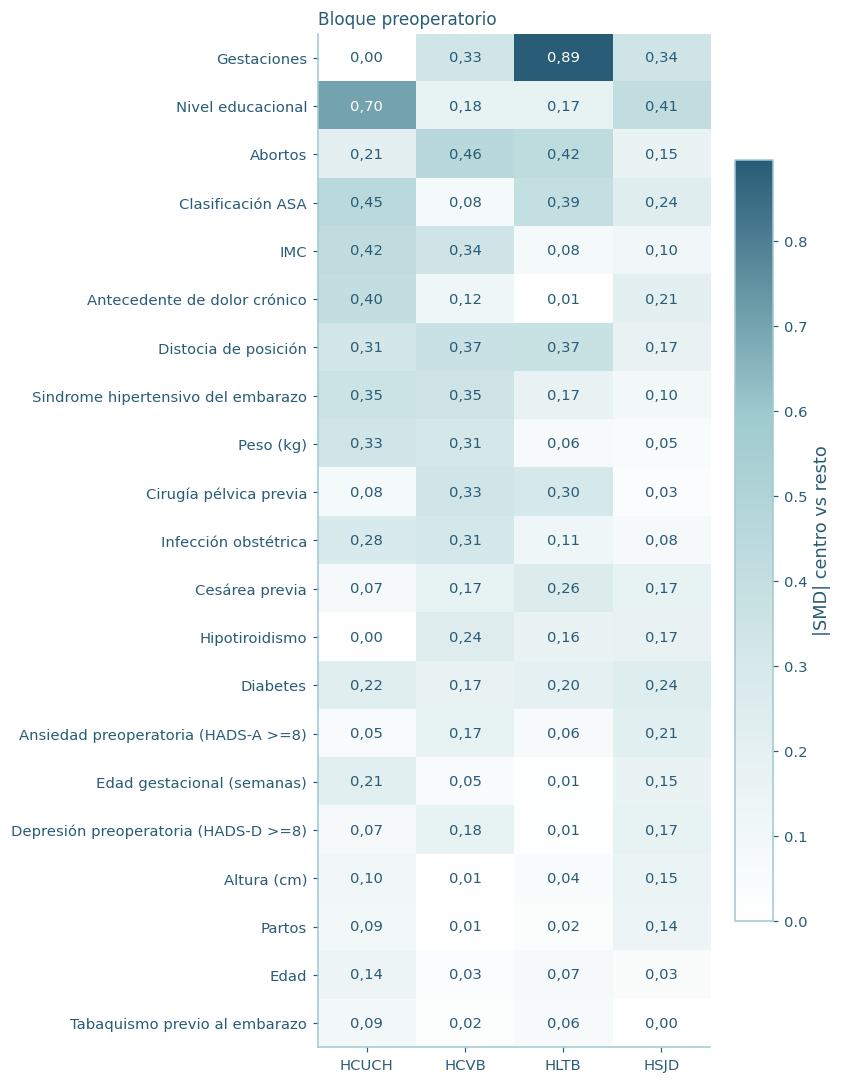

✔ fig_heatmap_intraop.png · fig_heatmap_intraop.svg


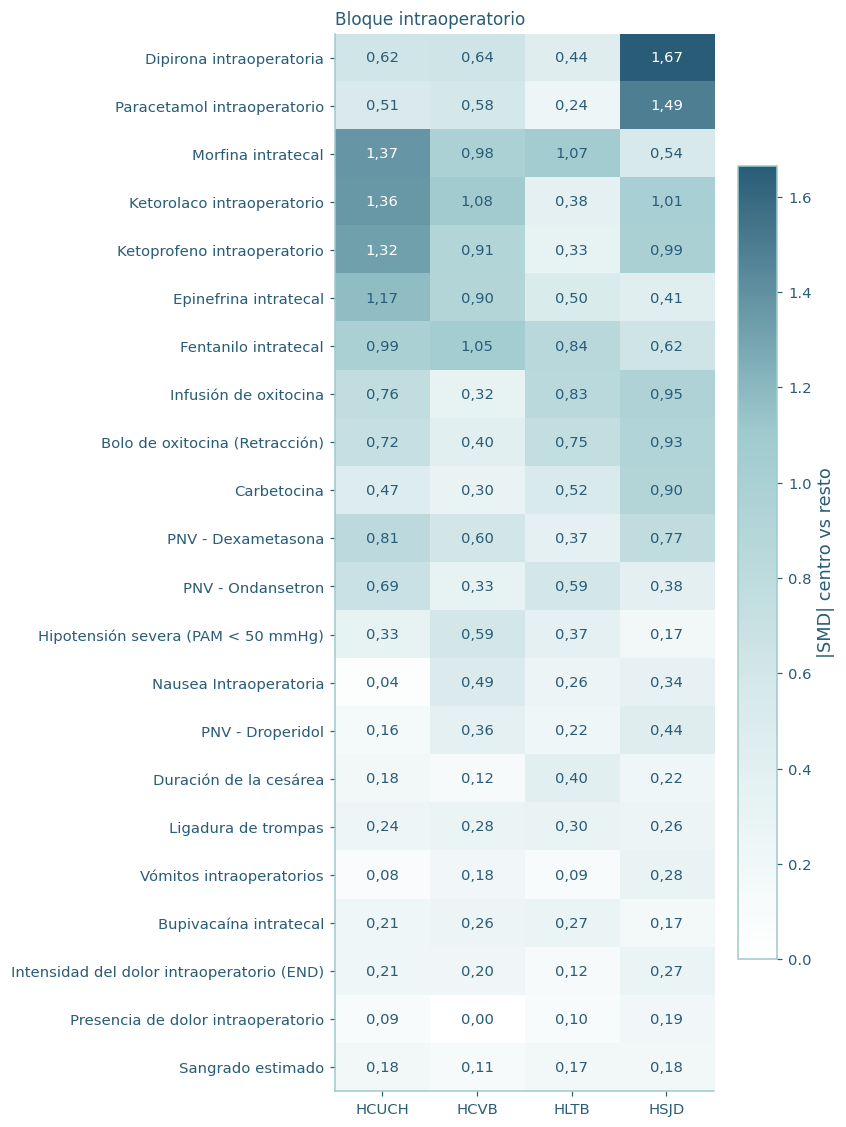

✔ fig_heatmap_postop.png · fig_heatmap_postop.svg


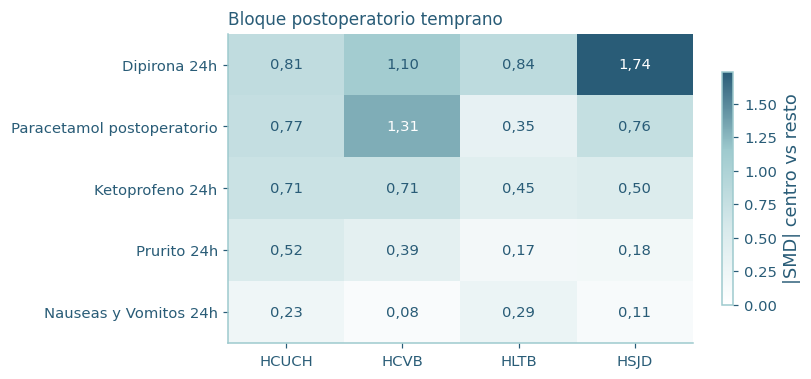

In [24]:
for bloque, titulo in [("preop", "Bloque preoperatorio"),
                       ("intraop", "Bloque intraoperatorio"),
                       ("postop", "Bloque postoperatorio temprano")]:
    m = vista.matriz_heterogeneidad(cohorte, catalogo, bloque)
    if not m.empty:
        fig = rendern.heatmap_heterogeneidad(m, titulo)
        rendern.guardar(fig, f"fig_heatmap_{bloque}")
        display(fig)

In [25]:
por_centro = vista.tabla_por_centro(cohorte, catalogo, heterogeneidad)
_centros = [c for c in por_centro.columns if c.endswith(")") and "n=" in c]
anexo_por_centro = tabula.tabla_por_centro(por_centro)
tabula.construir_docx(
    anexo_por_centro,
    tabula.Spec(config.TABLAS_MANUSCRITO["HET_por_centro"],
                "Características de la cohorte analítica por centro y magnitud de la heterogeneidad "
                "entre hospitales",
                nota="Continuas: mediana [RIC]. Categóricas: n/N (%) del nivel positivo o de las "
                     "expuestas a cualquier dosis, o nivel modal cuando no hay nivel de referencia. "
                     "La primera fila es la frecuencia del desenlace por centro, sin SMD por no ser "
                     "una covariable. Prueba global entre los cuatro hospitales: "
                     "χ² o Kruskal-Wallis (K-W). SMD: máxima diferencia estandarizada de un centro "
                     "frente al resto. En negrita, p < 0,05. La completitud del registro se examinó "
                     "por centro: gestaciones, partos, abortos y dipirona a las 24 h presentan "
                     "completitud dispar entre hospitales, de modo que su SMD debe leerse con cautela.",
                grupo="Bloque", cols=["Variable", "Faltantes", *_centros, "Test (p)",
                                      "SMD máx. (centro)"],
                pagina_completa=True))

anexo_por_centro

✔ tabla_HET_heterogeneidad_por_centro.docx  (49 filas)
✔ tabla_HET_heterogeneidad_por_centro.tex  (49 filas)  → requiere apaisada en el anexo


,Bloque,Variable,Faltantes,HCUCH (n=180),HCVB (n=198),HLTB (n=185),HSJD (n=151),Test (p),SMD máx. (centro),p
0,Desenlace,Dolor moderado a intenso durante la 1a. semana,"0 (0,0%)","125/180 (69,4%)","174/198 (87,9%)","66/185 (35,7%)","58/151 (38,4%)","χ² (< 0,001)",—,3.669139e-31
1,Preoperatorio,Abortos,"545 (76,3%)","1,0 [1,0–1,0]","1,0 [1,0–2,0]","1,0 [1,0–1,0]","1,0 [1,0–1,5]","K-W (0,062)","0,46 (HCVB)",6.220579e-02
2,Preoperatorio,Altura (cm),"4 (0,6%)","159,5 [156,0–163,0]","160,0 [155,0–164,0]","160,0 [155,0–164,0]","158,0 [154,0–162,0]","K-W (0,325)","0,15 (HSJD)",3.252752e-01
3,Preoperatorio,Ansiedad preoperatoria (HADS-A >=8),"5 (0,7%)","52/180 (28,9%)","64/195 (32,8%)","46/183 (25,1%)","30/151 (19,9%)","χ² (0,049)","0,21 (HSJD)",4.855337e-02
4,Preoperatorio,Antecedente de dolor crónico,"7 (1,0%)","1/180 (0,6%)","18/196 (9,2%)","13/183 (7,1%)","17/148 (11,5%)","χ² (< 0,001)","0,40 (HCUCH)",5.182341e-04
5,Preoperatorio,Cesárea previa,"0 (0,0%)","90/180 (50,0%)","117/198 (59,1%)","80/185 (43,2%)","90/151 (59,6%)","χ² (0,004)","0,26 (HLTB)",4.041715e-03
6,Preoperatorio,Cirugía pélvica previa,"0 (0,0%)","16/180 (8,9%)","37/198 (18,7%)","8/185 (4,3%)","15/151 (9,9%)","χ² (< 0,001)","0,33 (HCVB)",6.850972e-05
7,Preoperatorio,Clasificación ASA,"13 (1,8%)",II (100%),II (91%),II (84%),II (97%),"χ² (< 0,001)","0,45 (HCUCH)",1.747123e-08
8,Preoperatorio,Depresión preoperatoria (HADS-D >=8),"8 (1,1%)","12/180 (6,7%)","23/195 (11,8%)","15/180 (8,3%)","7/151 (4,6%)","χ² (0,088)","0,18 (HCVB)",8.812227e-02
9,Preoperatorio,Diabetes,"0 (0,0%)","27/180 (15,0%)","53/198 (26,8%)","29/185 (15,7%)","45/151 (29,8%)","χ² (< 0,001)","0,24 (HSJD)",5.312016e-04


## 8. Salidas y verificación

El cuaderno congela la cohorte analítica y la subcohorte espinal como artefactos con su firma, que
constituyen la entrada del cuaderno de modelamiento, junto al resultado del cribado. Las tablas y
figuras destinadas al manuscrito quedan además registradas en este mismo cuaderno.

In [26]:
h_cohorte = daten.congelar(cohorte, config.PROCESSED / "dataFONIS_prep.parquet")
h_espinal = daten.congelar(espinal, config.PROCESSED / "dataFONIS_prep_espinal.parquet")

config.OUTPUTS.mkdir(parents=True, exist_ok=True)
cribado.to_parquet(config.CRIBADO, index=False)
print(f"✔ cribado derivado → {config.CRIBADO.name}")

✔ dataFONIS_prep.parquet: 714 filas · 142 columnas · sha256 d310f992f4ba0421
✔ dataFONIS_prep_espinal.parquet: 690 filas · 142 columnas · sha256 a4e9babd42ffc5b1
✔ cribado derivado → cribado.parquet
